Kuchuru Sai Krishna Reddy
Internship Week-1 Project

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Task 1 – Data Loading & Exploration

In [4]:
df = pd.read_csv("Housing.csv")

print(df.head(10))

print("Rows and Columns:", df.shape)

print(df.columns)

print(df.isnull().sum())

X = df.drop("price", axis=1)
y = df["price"]

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

Task 2 – Data Cleaning

In [7]:
df = df.drop_duplicates()

print(df.isnull().sum())

df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          Tr

Task 3 – Model Building

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import numpy as np

X = df.drop("price", axis=1)
y = df["price"]

categorical_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

# Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Linear Regression
MAE: 970043.4039201695
RMSE: 1324506.9600914533
R2: 0.6529242642153106

Random Forest
MAE: 1011749.7369266056
RMSE: 1396007.3602735272
R2: 0.6144407031752304


Task 4 – Visualizations


Chart 1: House Price Distribution

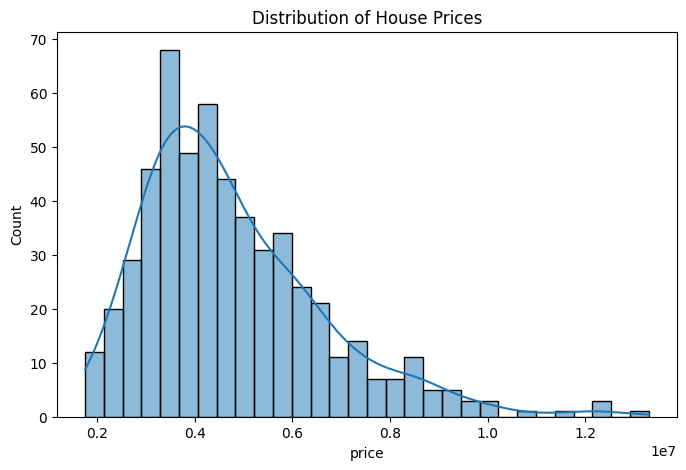

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

Chart 2: Correlation Heatmap

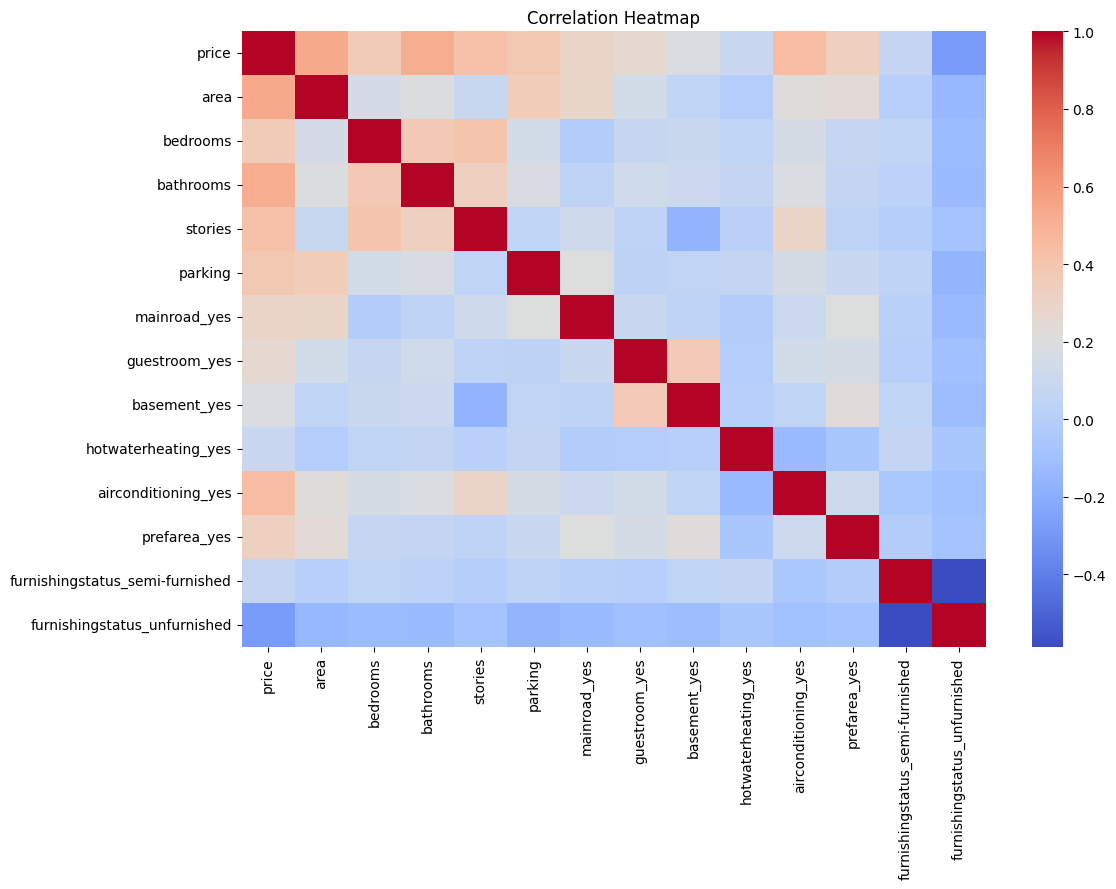

In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(),
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Chart 3: Actual vs Predicted Prices

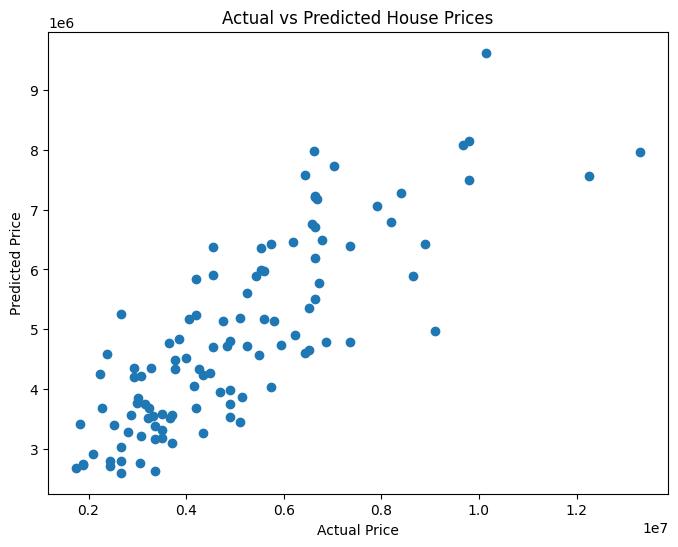

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

Task 5 – Insights & Summary

The analysis showed that area, number of bathrooms, air conditioning, number of stories, and parking spaces were among the strongest factors influencing house prices. The Linear Regression model achieved an R² score of approximately 0.65, meaning it explained about 65% of the variation in house prices. This indicates reasonably good predictive performance for a simple regression model. One interesting observation was that features such as air conditioning and preferred area had a stronger impact on price than expected. The dataset contained no missing values, which simplified the data preparation process. Comparing models, Linear Regression slightly outperformed Random Forest on this dataset. Based on these findings, real estate businesses should focus on highlighting property size, bathrooms, parking availability, and premium amenities when pricing and marketing houses.